# MVP — Machine Learning & Analytics

**Nome:** Bruno Rocha do Nascimento

**Matrícula:** 4052025002341

**Data:** 05/07/2026  

**Dataset:** [Predicting Hiring Decisions in Recruitment Data](https://raw.githubusercontent.com/BrunoSennin/MVP_ML_Bruno-Rocha-do-Nascimento/refs/heads/main/recruitment_data.csv)

**Tipo de problema:** Classificação


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema



## 1.1 Descrição do problema

O processo de recrutamento e seleção é uma das atividades mais críticas e custosas nas organizações. Uma decisão equivocada de contratação pode gerar impactos financeiros, culturais e operacionais significativos.

Em processos seletivos com grande volume de candidatos, a análise manual dessas informações pode demandar tempo considerável, além de dificultar a padronização dos critérios de avaliação. Nesse contexto, técnicas de Machine Learning podem atuar como ferramentas de apoio à tomada de decisão, auxiliando os profissionais de Recursos Humanos na priorização dos candidatos com maior potencial de aderência à vaga, sem substituir a avaliação humana.

Dessa forma, este projeto propõe a aplicação da seguinte abordagem:

- **Classificação:** desenvolver um modelo capaz de estimar a probabilidade de um candidato ser recomendado para contratação, com base em suas características pessoais, profissionais e no desempenho obtido durante as etapas do processo seletivo.

O principal usuário desta solução seria a equipe de Recursos Humanos no processo de Recrutamento & Seleção, podendo também apoiar gestores requisitantes durante o processo seletivo.

## 1.2 Objetivo do MVP

A proposta deste MVP não é substituir a decisão humana no processo de recrutamento e seleção, mas aplicar técnicas de Machine Learning para identificar padrões nos dados dos candidatos, apoiar a triagem inicial de currículos e fornecer evidências analíticas que auxiliem os profissionais de Recursos Humanos na tomada de decisões mais consistentes e fundamentadas. Espera-se, com isso, contribuir para a redução do tempo de análise, a padronização dos critérios de avaliação e uma melhor compreensão dos perfis de candidatos presentes no processo seletivo.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação.

**Justificativa:** O problema deste projeto é caracterizado como uma tarefa de classificação supervisionada, pois o objetivo é prever uma categoria previamente conhecida: a contratação ou não contratação de um candidato. O dataset utilizado possui uma variável-alvo que representa o resultado do processo seletivo, permitindo que modelos de Machine Learning aprendam padrões a partir de exemplos históricos e realizem previsões para novos candidatos.

## 1.4 Premissas, hipóteses e critérios de sucesso

Assume-se que os dados históricos do processo seletivo contêm informações suficientes e consistentes para permitir a identificação de padrões relacionados à contratação de candidatos por meio de técnicas de Machine Learning.

**Hipóteses iniciais:**

1. Candidatos com melhor desempenho em entrevistas, testes técnicos e avaliação de habilidades tendem a apresentar maior probabilidade de recomendação para contratação.

2. Variáveis relacionadas à experiência profissional, formação acadêmica e desempenho no processo seletivo possuem relação relevante com a decisão final de contratação.

3. A variável de estratégias de recrutamento gera impacto significativo no modelo.

**Critérios de sucesso:**

**Métrica principal:**
F1-score, pois o problema envolve classificação e é importante equilibrar precisão e recall na identificação de candidatos recomendados para contratação.

**Resultado mínimo esperado:**
O modelo final deverá superar o baseline em pelo menos 10% no F1-score.

**Restrição prática:**
O modelo deve ser simples, interpretável e de baixo custo computacional, permitindo que os resultados sejam compreendidos por profissionais de RH e utilizados como apoio à triagem, sem substituir a decisão humana.



# 2. Ambiente, bibliotecas e reprodutibilidade (Pendente)


## 2.1. Bibliotecas utilizadas

As versões das principais bibliotecas podem ser obtidas por meio do código abaixo:

In [95]:
# Bibliotecas principais
# Manipulação, análise de dados, operações matemáticas e manipulação de arrays
import pandas as pd
import numpy as np
import time

# Visualização gráfica dos dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento, modelagem, avaliação de modelos de classificação.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (LabelEncoder, StandardScaler, OneHotEncoder)
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, silhouette_score,
                             precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

## 2.2. Reprodutibilidade

Para garantir a reprodutibilidade dos resultados, foi definida uma semente aleatória fixa (random seed) utilizada nas etapas de particionamento dos dados, treinamento dos modelos, como segue:

In [96]:
SEED = 42
np.random.seed(SEED)

Para garantir a reprodutibilidade dos resultados, foi definida uma semente aleatória fixa (SEED = 42), utilizada nos procedimentos que envolvem aleatoriedade, como a divisão dos conjuntos de treino e teste e a execução dos algoritmos.

## 2.3. GPU/CPU e Versionamento

Os experimentos serão executados utilizando os recursos padrão do Google Colab. Considerando o tamanho do conjunto de dados e os algoritmos inicialmente previstos para o estudo, não se espera a necessidade de recursos computacionais especializados.

As versões das bibliotecas se apresentam como:

In [97]:
import sys
print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("Scikit-learn:", __import__('sklearn').__version__)
print("Seed fixada:", SEED)

Python: 3.12.13
Pandas: 2.2.2
Scikit-learn: 1.6.1
Seed fixada: 42


## 2.2 Funções auxiliares (Pendente)

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


# 3. Seleção e carga dos dados



## 3.1 Fonte dos dados

- **Nome do dataset:** Predicting Hiring Decisions in Recruitment Data  
- **Fonte:** Kaggle — [https://www.kaggle.com/datasets/rabieelkharoua/predicting-hiring-decisions-in-recruitment-data](https://www.kaggle.com/datasets/rabieelkharoua/predicting-hiring-decisions-in-recruitment-data)  
- **Por que foi escolhido:** O dataset é diretamente relevante ao problema de negócio proposto (recrutamento e seleção), possui variáveis claras e interpretáveis para o domínio de RH, contém uma variável-alvo relacionada à decisão de contratação e está disponível para uso público sem restrições de licença que impeçam sua utilização acadêmica.  
- **Questões éticas:** O dataset é sintético e não contém informações pessoais identificáveis.
- **Limitações conhecidas:** Dataset sintético, o que pode não capturar a complexidade e os vieses reais de processos seletivos.



## 3.2 Carga dos dados

O dataset foi disponibilizado em um repositório público no GitHub para garantir a reprodutibilidade do projeto e permitir a execução do notebook sem necessidade de autenticação em plataformas externas ou upload manual de arquivos.

O carregamento foi realizado utilizando a biblioteca Pandas, conforme apresentado abaixo:

In [98]:
# === Carga dos dados ===

Data_Recruitment = False

if Data_Recruitment:
    print("Modo exemplo ativado.")
else:
    DATA_URL = "https://raw.githubusercontent.com/BrunoSennin/MVP_ML_Bruno-Rocha-do-Nascimento/main/recruitment_data.csv"

    # Carregamento da base real
    df = pd.read_csv(DATA_URL)

df.head()


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


## 3.3 Visão geral do dataset

Nesta seção é apresentada uma visão geral do conjunto de dados, incluindo sua dimensão, tipos de atributos, presença de valores ausentes e duplicados, além da identificação de possíveis variáveis que não devem participar da modelagem e da análise preliminar da variável-alvo.

In [99]:
# Quantidade de Linhas e Colunas
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 1500
Quantidade de colunas: 11


In [100]:
# Tipos de Atributos
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (1500, 11)

Tipos de dados:


,tipo
Age,int64
Gender,int64
EducationLevel,int64
ExperienceYears,int64
PreviousCompanies,int64
DistanceFromCompany,float64
InterviewScore,int64
SkillScore,int64
PersonalityScore,int64
RecruitmentStrategy,int64


In [101]:
# Valores Ausentes
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Age,0
Gender,0
EducationLevel,0
ExperienceYears,0
PreviousCompanies,0
DistanceFromCompany,0
InterviewScore,0
SkillScore,0
PersonalityScore,0
RecruitmentStrategy,0


In [102]:
# Valores Duplicados
print("\nDuplicatas:", df.duplicated().sum())


Duplicatas: 0


### 3.3.1 Varáveis e Target

Não foram identificadas colunas de identificação única (ID) ou datas que exijam remoção imediata. Todas as variáveis serão inicialmente mantidas para análise exploratória. A necessidade de exclusão de atributos será reavaliada após a investigação de sua relevância para o problema de negócio.

O Target selecionado para o problema de classificação é HiringDecision, que representa o resultado final do processo seletivo. Os valores possíveis são 0 (não contratado) e 1 (contratado).

## 3.4 Dicionário de dados

O dicionário de dados apresenta os principais atributos do dataset, seus tipos, descrições e a indicação preliminar de uso na modelagem. Neste momento, as variáveis explicativas serão mantidas para análise, e eventuais exclusões serão avaliadas nas etapas de exploração, pré-processamento e modelagem.

| Coluna | Tipo | Descrição | Modelo? | Observações |
|---|---|---|---|---|
| Age | Numérica (int) | Idade do candidato (20–50 anos) | Sim | Pode influenciar padrões de contratação |
| Gender | Categórica (0/1) | Gênero do candidato (0=Feminino, 1=Masculino) | Sim | Deve ser avaliada com cuidado por possível viés |
| EducationLevel | Ordinal (1–4) | Nível de escolaridade (1=Ensino Médio, 2=Bacharelado, 3=Mestrado, 4=Doutorado) | Sim | Pode ser relevante para o perfil da vaga |
| ExperienceYears | Numérica (int) | Anos de experiência profissional (0–15) | Sim | Variável relevante para decisão de contratação |
| PreviousCompanies | Numérica (int) | Número de empresas anteriores (1–5) | Sim | Pode indicar trajetória profissional|
| DistanceFromCompany | Numérica (float) | Distância em km do candidato até a empresa | Sim | Mantida inicialmente para análise exploratória |
| InterviewScore | Numérica (int) | Pontuação obtida na entrevista (0–100) | Sim | Variável diretamente relacionada ao processo seletivo |
| SkillScore | Numérica (int) | Pontuação em avaliação de habilidades técnicas (0–100) | Sim | Representa avaliação de competências |
| PersonalityScore | Numérica (int) | Pontuação em avaliação comportamental (0–100) | Sim |Representa avaliação comportamental|
| RecruitmentStrategy | Categórica (1–3) | Estratégia de recrutamento utilizada (1=Agressiva, 2=Moderada, 3=Conservadora) | Sim | Pode indicar diferenças entre fontes de recrutamento |
| HiringDecision | Binária (0/1) | Resultado final da contratação | Alvo | **Target:** 0=Não contratar, 1=Contratar |

# 4. Análise exploratória dos dados

Esta etapa tem como objetivo explorar os dados e identificar padrões relevantes para o problema de predição de contratação. Serão analisadas a distribuição da variável-alvo, as características das principais variáveis explicativas, a relação entre os atributos e o resultado da contratação, além da existência de desbalanceamento, outliers e possíveis correlações entre variáveis. Os resultados obtidos nesta fase servirão de apoio para decisões de pré-processamento, seleção de atributos e construção dos modelos de Machine Learning.

## 4.1 Distribuição do Target

Conforme informado anteriormente a variável Target é **Hiring Decision**. A análise de sua distribuição é importante para verificar a proporção entre as classes e identificar possíveis desbalanceamentos que possam impactar o treinamento e a avaliação dos modelos de Machine Learning.

In [103]:
TARGET = "HiringDecision"

target_map = { 0: "Não Contratado (0)",
               1: "Contratado (1)"}

target_descricao = df[TARGET].map(target_map)

contagem = target_descricao.value_counts()
percentual = target_descricao.value_counts(normalize=True) * 100

print("Distribuição do target (HiringDecision):")

display(contagem.to_frame("Contagem"))
display(percentual.round(2).to_frame("Percentual (%)"))


Distribuição do target (HiringDecision):


,Contagem
HiringDecision,
Não Contratado (0),1035
Contratado (1),465


,Percentual (%)
HiringDecision,
Não Contratado (0),69.0
Contratado (1),31.0


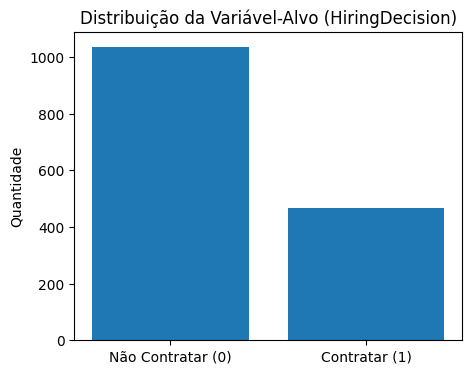

In [104]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Não Contratar (0)", "Contratar (1)"], contagem.values)
ax.set_title("Distribuição da Variável-Alvo (HiringDecision)")
ax.set_ylabel("Quantidade")
plt.show()

Observa-se um desbalanceamento entre as classes, sendo aproximadamente 69% dos registros classificados como "Não Contratado" e 31% como "Contratado", logo a distribuição não é equilibrada.

Isso justifica a utilização do **F1-Score** como principal métrica de avaliação oferecendo uma visão mais adequada do desempenho em bases desbalanceadas.


## 4.2 Estatisticas Descritiva

Antes de avaliar as relações entre as variáveis, é importante compreender suas características individuais. A análise descritiva permite identificar tendências centrais, dispersão dos dados e possíveis valores extremos, fornecendo uma visão inicial do comportamento dos candidatos presentes na base.



In [105]:
# Análise Descritiva
print("Estatísticas descritivas:")
display(df.describe().round(2))

Estatísticas descritivas:


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,35.15,0.49,2.19,7.69,3.00,25.51,50.56,51.12,49.39,1.89,0.31
std,9.25,0.50,0.86,4.64,1.41,14.57,28.63,29.35,29.35,0.69,0.46
min,20.00,0.00,1.00,0.00,1.00,1.03,0.00,0.00,0.00,1.00,0.00
25%,27.00,0.00,2.00,4.00,2.00,12.84,25.00,25.75,23.00,1.00,0.00
50%,35.00,0.00,2.00,8.00,3.00,25.50,52.00,53.00,49.00,2.00,0.00
75%,43.00,1.00,3.00,12.00,4.00,37.74,75.00,76.00,76.00,2.00,1.00
max,50.00,1.00,4.00,15.00,5.00,50.99,100.00,100.00,100.00,3.00,1.00


As variáveis de avaliação dos candidatos apresentam elevada variabilidade, característica favorável para a construção de modelos preditivos.

## 4.3 Matriz de Correlação

Antes de analisar individualmente as variáveis, é importante compreender o grau de associação existente entre os atributos numéricos. Correlações elevadas podem indicar redundância de informações, enquanto correlações próximas de zero podem sugerir baixo potencial explicativo para o problema de contratação.

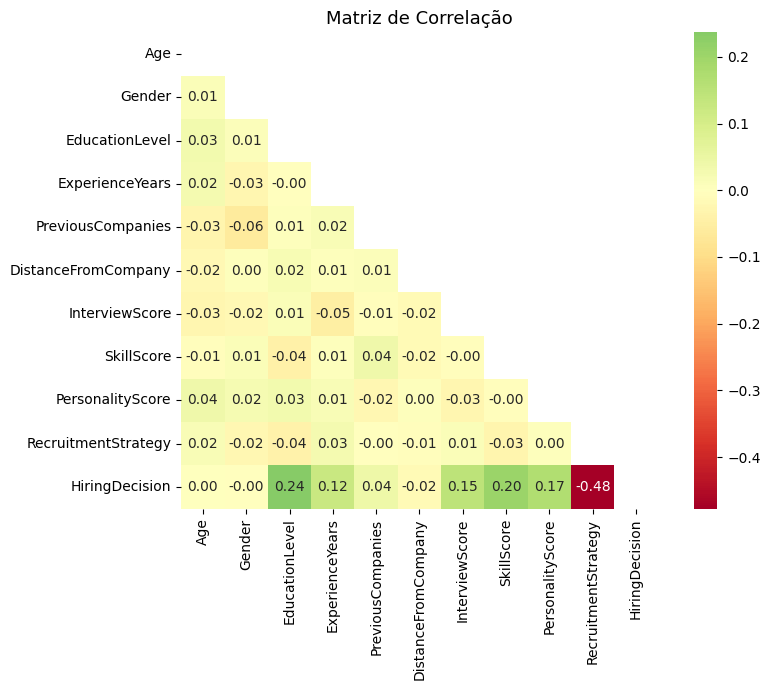

In [106]:
# Matriz de correlação
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, ax=ax)
ax.set_title("Matriz de Correlação", fontsize=13)
plt.tight_layout()
plt.show()


A análise de correlação não identificou relações fortes entre as variáveis explicativas, indicando baixa redundância entre os atributos do dataset. Em relação à variável-alvo, EducationLevel apresentou a maior correlação positiva (0,24), seguida por SkillScore (0,20), PersonalityScore (0,17) e InterviewScore (0,15).

As variáveis Age, Gender, PreviousCompanies e DistanceFromCompany apresentaram correlações muito próximas de zero com a variável-alvo. Esse resultado sugere baixa influência linear dessas características sobre a decisão de contratação.

Embora RecruitmentStrategy tenha apresentado a maior correlação com a variável-alvo (-0,48), essa variável representa uma característica do processo de recrutamento e não diretamente ao candidato. Dessa forma, sua interpretação será feita com cautela, priorizando a análise de atributos diretamente relacionados ao perfil e desempenho dos candidatos.

## 4.4 Análise das váriáveis

Após a análise de correlação, torna-se importante verificar como as principais variáveis se comportam em relação ao resultado da contratação. Para isso, serão comparadas as distribuições dos atributos entre candidatos contratados e não contratados, buscando identificar diferenças que possam auxiliar na construção dos modelos preditivos.

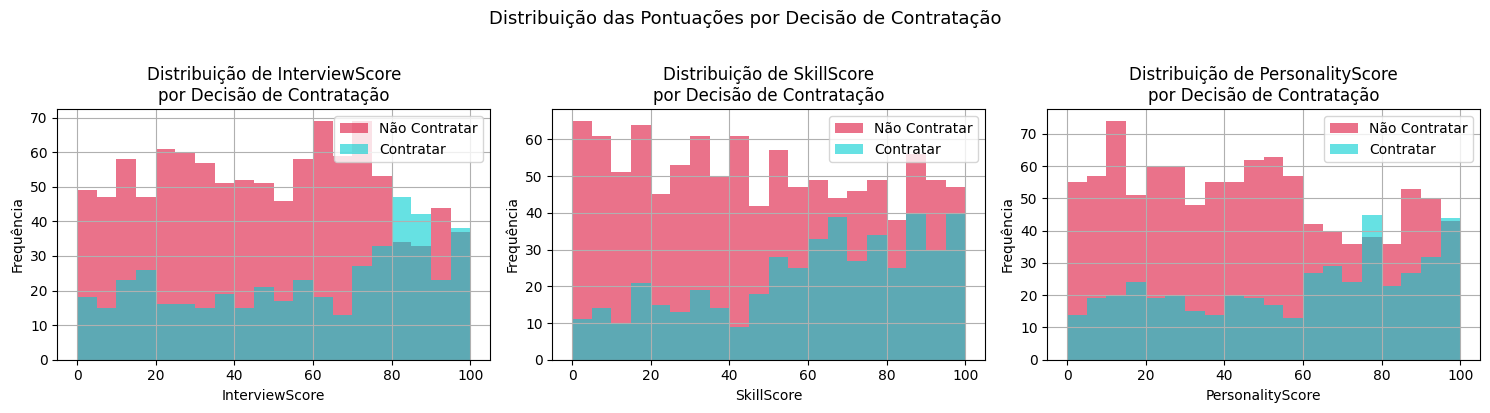

In [107]:
# Distribuição das variáveis de pontuação por decisão de contratação
score_cols = ["InterviewScore", "SkillScore", "PersonalityScore"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(score_cols):
    ax = axes[i]
    for label, color, name in [(0, "#DC143C", "Não Contratar"), (1, "#00CED1", "Contratar")]:
        df[df[TARGET] == label][col].hist(bins=20, alpha=0.6, color=color, label=name, ax=ax)
    ax.set_title(f"Distribuição de {col}\npor Decisão de Contratação")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
    ax.legend()

plt.suptitle("Distribuição das Pontuações por Decisão de Contratação", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Os histogramas indicam que candidatos contratados tendem a apresentar pontuações mais elevadas em InterviewScore, SkillScore e PersonalityScore quando comparados aos não contratados.
Entretanto, existe considerável sobreposição entre as distribuições dos grupos, indicando que nenhuma dessas variáveis, isoladamente, é capaz de explicar completamente a decisão de contratação. Esse comportamento sugere que a contratação resulta da combinação de múltiplos fatores avaliados em conjunto.

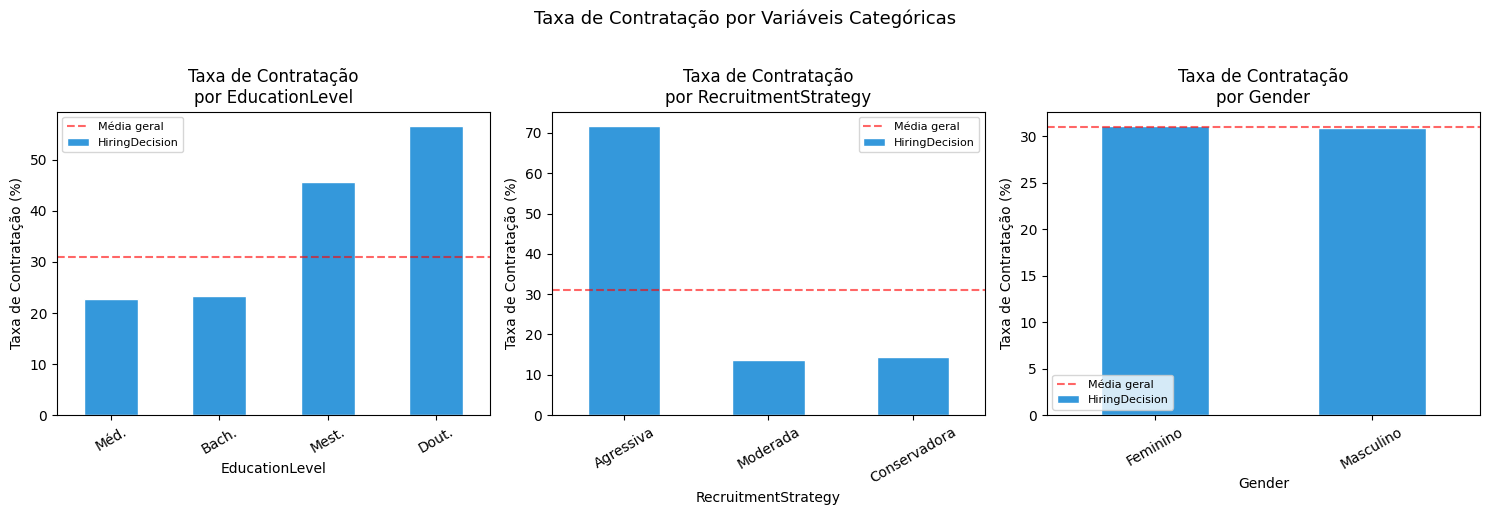

In [108]:
# Análise da Taxa de Contratação por Variável categórica
cat_cols_plot = ["EducationLevel", "RecruitmentStrategy", "Gender"]
cat_labels = {
    "EducationLevel": {1: "Méd.", 2: "Bach.", 3: "Mest.", 4: "Dout."},
    "RecruitmentStrategy": {1: "Agressiva", 2: "Moderada", 3: "Conservadora"},
    "Gender": {0: "Feminino", 1: "Masculino"}
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols_plot):
    ax = axes[i]
    taxa = df.groupby(col)[TARGET].mean() * 100
    taxa.index = [cat_labels[col].get(k, k) for k in taxa.index]
    taxa.plot(kind="bar", ax=ax, color="#3498db", edgecolor="white")
    ax.set_title(f"Taxa de Contratação\npor {col}")
    ax.set_ylabel("Taxa de Contratação (%)")
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(df[TARGET].mean() * 100, linestyle="--", color="red", alpha=0.6,
               label="Média geral")
    ax.legend(fontsize=8)

plt.suptitle("Taxa de Contratação por Variáveis Categóricas", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

A análise das variáveis categóricas demonstrou que EducationLevel e RecruitmentStrategy apresentam associação relevante com a decisão de contratação. Observou-se aumento consistente da taxa de contratação conforme o nível de escolaridade se eleva, com destaque para candidatos com mestrado e doutorado. Além disso, a estratégia de recrutamento agressiva apresentou taxa de contratação significativamente superior às demais categorias. Por outro lado, a variável Gender apresentou taxas praticamente idênticas entre os grupos analisados, não indicando influência relevante sobre a contratação.


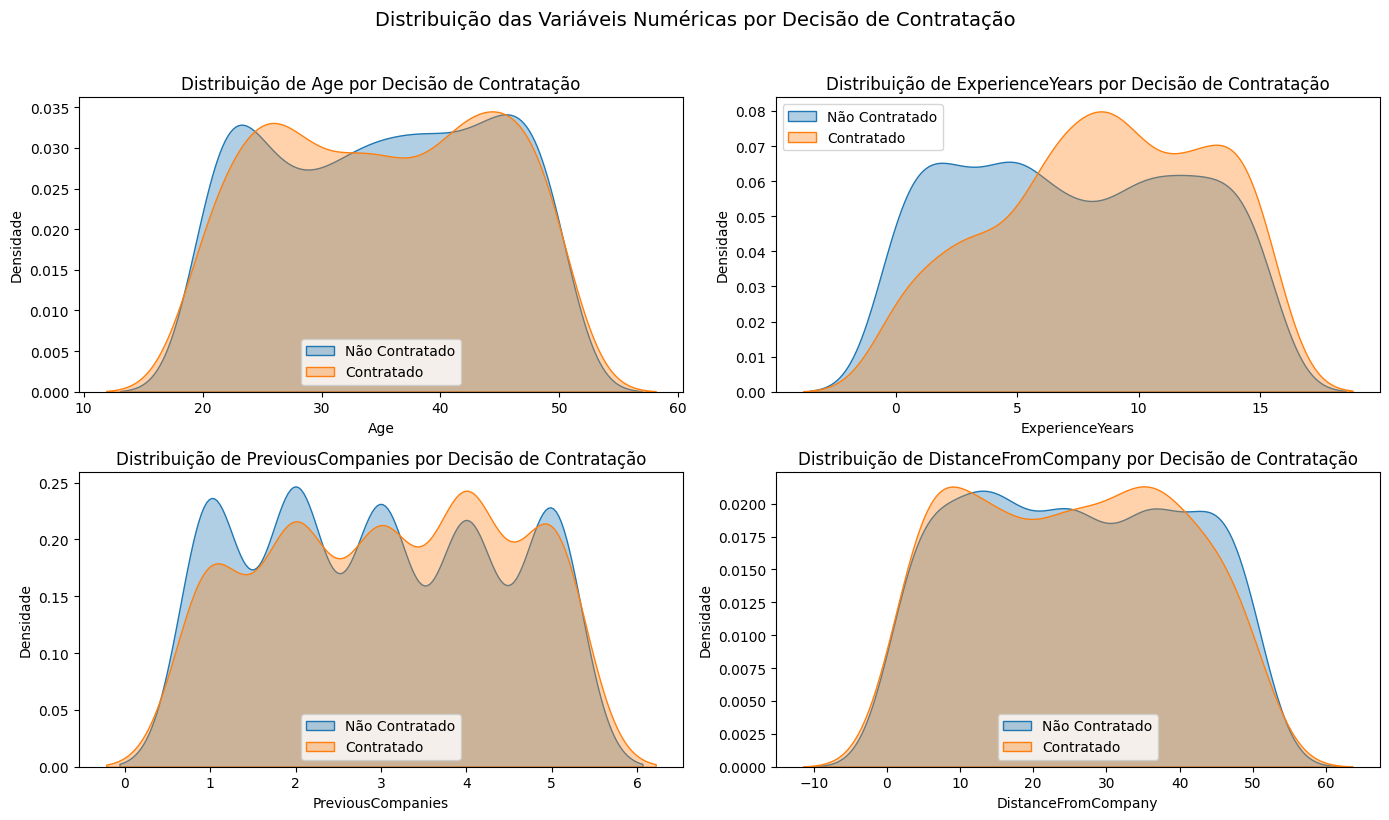

In [109]:
# Distribuição das variáveis numéricas por decisão de contratação
kde_cols = ["Age","ExperienceYears","PreviousCompanies","DistanceFromCompany"]
target_labels = {0: "Não Contratado",1: "Contratado"}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(kde_cols):
    ax = axes[i]
    for label, name in target_labels.items():
        sns.kdeplot(
            data=df[df[TARGET] == label],
            x=col,
            fill=True,
            alpha=0.35,
            label=name,
            ax=ax)

    ax.set_title(f"Distribuição de {col} por Decisão de Contratação")
    ax.set_xlabel(col)
    ax.set_ylabel("Densidade")
    ax.legend()

plt.suptitle("Distribuição das Variáveis Numéricas por Decisão de Contratação", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Entre as variáveis numéricas analisadas, apenas ExperienceYears apresentou evidências visuais consistentes de associação com a contratação. Age e DistanceFromCompany exibiram distribuições praticamente idênticas entre os grupos, sugerindo baixo poder discriminatório individual.

PreviousCompanies apresentou comportamento semelhante entre os grupos, não indicando influência significativa sobre a contratação.

## 4.5 Síntese da análise exploratória

**Principais achados:**

1. **Desbalanceamento:** aproximadamente 69% dos candidatos não foram contratados e 31% foram contratados. Essa característica justifica o uso do F1-Score como principal métrica de avaliação e poderá motivar testes com técnicas de balanceamento.

2. **Variáveis mais promissoras:** InterviewScore, SkillScore e PersonalityScore apresentaram a maior separação entre os grupos de candidatos contratados e não contratados, indicando potencial relevância para os modelos preditivos.

3. **Experiência profissional:** candidatos contratados tendem a apresentar maiores valores de ExperienceYears, sugerindo associação positiva com a contratação.

4. **Ausência de valores nulos:** não foram identificados dados faltantes, dispensando tratamentos de imputação.

5. **Escalas distintas:** as variáveis numéricas apresentam magnitudes diferentes, indicando a necessidade de padronização para algoritmos sensíveis à escala.

6. **Baixa influência individual:** Age, Gender, PreviousCompanies e DistanceFromCompany apresentaram distribuições semelhantes entre os grupos, sugerindo menor poder discriminatório individual.

7. **RecruitmentStrategy:** apresentou forte associação com a variável-alvo, porém representa uma característica do processo seletivo e não do perfil dos candidatos, devendo ser avaliada com cautela na modelagem.

8. **Estratégia de modelagem:** os resultados da análise exploratória indicam potencial para modelos de classificação supervisionada e motivam experimentos com diferentes conjuntos de variáveis para avaliar seu impacto na capacidade preditiva.


# 5. Preparação dos dados e divisão treino/teste

Após a análise exploratória, inicia-se a etapa de preparação dos dados para a modelagem. Nesta fase, são definidas as variáveis preditoras (*features*) e a variável-alvo (*target*), além da estratégia de divisão dos dados entre os conjuntos de treino e teste.


In [110]:
# Configuração do problema de classificação
TARGET = "HiringDecision"

# Colunas a excluir do modelo
# Neste primeiro experimento, nenhuma coluna será removida
DROP_COLUMNS = []

features = [c for c in df.columns if c != TARGET and c not in DROP_COLUMNS]

print("Target:", TARGET)
print(f"Número de features: {len(features)}")
print("Features:", features)

Target: HiringDecision
Número de features: 10
Features: ['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy']


In [111]:
# Divisão treino/teste para classificação
X = df[features].copy()
y = df[TARGET].copy()

# Estratificação para manter proporção do target nos dois conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape[0]} registros | Teste: {X_test.shape[0]} registros")
print(f"\nProporção do target no treino:")
display((y_train.value_counts(normalize=True) * 100).round(2).to_frame("%"))
print(f"\nProporção do target no teste:")
display((y_test.value_counts(normalize=True) * 100).round(2).to_frame("%"))

Treino: 1200 registros | Teste: 300 registros

Proporção do target no treino:


,%
HiringDecision,
0,69.0
1,31.0



Proporção do target no teste:


,%
HiringDecision,
0,69.0
1,31.0


## 5.1 Justificativa da divisão

- **Estratégia utilizada:** foi adotada a abordagem holdout, com separação dos dados em conjuntos de treino e teste. Foi utilizada uma divisão de 80% dos registros para treinamento e 20% para teste. Essa estratégia é suficiente dado o tamanho do dataset (1.500 registros). O conjunto de teste com 300 registros é estatisticamente representativo para estimativa de desempenho.

- **Estratificação das classes:** foi aplicada estratificação da variável-alvo (*HiringDecision*) durante a divisão dos dados. Essa decisão foi necessária devido ao desbalanceamento moderado identificado na análise exploratória (aproximadamente 69% de candidatos não contratados e 31% contratados), garantindo que a distribuição das classes fosse preservada nos conjuntos de treino e teste.

- **Prevenção de vazamento de dados:** a divisão entre treino e teste foi realizada antes das etapas de transformação dos dados. Dessa forma, procedimentos como codificação de variáveis categóricas, padronização e eventuais seleções de atributos serão ajustados apenas com os dados de treinamento, evitando que informações do conjunto de teste influenciem o processo de aprendizagem dos modelos.

- **Validação futura:** embora a estratégia principal seja holdout, técnicas de validação cruzada poderão ser utilizadas posteriormente durante a etapa de otimização de hiperparâmetros, visando obter estimativas mais robustas de desempenho dos modelos.

# 6. Pré-processamento e pipeline

Essa etapa é necessária porque o conjunto de dados contém variáveis numéricas em diferentes escalas e variáveis categóricas que precisam ser convertidas para formato numérico.

Como não foram identificados valores ausentes na análise exploratória, não será necessário aplicar imputação. Ainda assim, o pré-processamento será organizado em um _Pipeline_, garantindo que transformações como padronização e codificação sejam ajustadas apenas com os dados de treino e posteriormente aplicadas ao conjunto de teste. Essa abordagem reduz o risco de vazamento de dados e torna o fluxo de modelagem mais consistente e reproduzível.

In [112]:
# Identificação dos tipos de variáveis
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

# Pré-processamento das variáveis numéricas e categóricas
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[("encoder",
                          OneHotEncoder(handle_unknown="ignore"))])

# Pipeline de pré-processamento
preprocess = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)])


Variáveis numéricas: ['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy']
Variáveis categóricas: []


Embora _Gender_ e _RecruitmentStrategy_ representem categorias codificadas numericamente, inicialmente iremos manter em formato numérico para simplificar o pipeline de pré-processamento. Como _Gender_ é uma variável binária e EducationLevel possui natureza ordinal, essa representação não compromete significativamente a modelagem. Para _RecruitmentStrategy_, futuras versões do trabalho poderiam avaliar o uso de One-Hot Encoding e comparar seus impactos no desempenho dos modelos.

## 6.1 Decisões de pré-processamento

**Principais decisões adotadas:**

- **Padronização dos dados:** foi utilizado o _StandardScaler_ para padronizar as variáveis numéricas, transformando-as para média igual a zero e desvio padrão igual a um. Essa etapa reduz o impacto das diferenças de escala entre os atributos e beneficia algoritmos sensíveis à magnitude dos dados, como a Regressão Logística.

- **Tratamento das variáveis:** todas as variáveis foram mantidas em formato numérico. A variável _EducationLevel_ possui natureza ordinal e sua representação numérica preserva a ordem entre os níveis de escolaridade. As variáveis _Gender_ e _RecruitmentStrategy_, embora representem categorias codificadas, também foram mantidas em formato numérico para simplificar os experimentos iniciais do MVP.

- **Seleção de atributos:** nenhuma variável foi removida nesta etapa. Todos os atributos disponíveis foram mantidos para avaliar sua contribuição ao desempenho dos modelos. Experimentos posteriores poderão analisar o impacto da remoção de variáveis específicas, como _RecruitmentStrategy_.

- **Pipeline de pré-processamento:** as transformações foram organizadas por meio de um pipeline reprodutível, permitindo que os parâmetros sejam ajustados apenas com os dados de treinamento e posteriormente aplicados ao conjunto de teste.

- **Prevenção de vazamento de dados:** a separação entre treino e teste foi realizada antes das transformações. Dessa forma, informações do conjunto de teste não influenciam o processo de treinamento e ajuste dos modelos.

# 7. Baseline e modelos candidatos

Após a preparação dos dados, foram selecionados modelos de aprendizado de máquina para prever a variável-alvo _HiringDecision_. Antes da avaliação dos algoritmos principais, foi definido um modelo baseline, que servirá como referência mínima de desempenho.

As subseções seguintes apresentam o baseline adotado e os modelos candidatos selecionados para comparação.

In [113]:
# Definição do baseline e modelos candidatos

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
 "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "DecisionTree": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=5, random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=100, random_state=SEED))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ])
}

print("Baseline:", baseline.steps[-1][1].__class__.__name__)
print("Candidatos:", list(candidates.keys()))

Baseline: DummyClassifier
Candidatos: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'GradientBoosting']


## 7.1 Justificativa dos modelos

- **Baseline (DummyClassifier):** utilizado como referência mínima de desempenho, prevendo sempre a classe majoritária. Permite verificar se os modelos candidatos realmente aprendem padrões relevantes dos dados.

- **Regressão Logística:** escolhida por ser um modelo amplamente utilizado em classificação binária, com boa interpretabilidade e baixo custo computacional.

- **Decision Tree:** selecionada por sua capacidade de capturar relações não lineares e gerar regras de decisão facilmente compreensíveis.

- **Random Forest:** incluída por combinar múltiplas árvores de decisão, reduzindo o risco de overfitting e aumentando a capacidade de generalização.

- **Gradient Boosting:** escolhido por seu elevado potencial preditivo em dados tabulares, sendo frequentemente utilizado em problemas de classificação supervisionada.

- **Adequação ao problema:** todos os modelos selecionados são apropriados para classificação binária em datasets tabulares de pequeno e médio porte, como o conjunto de dados utilizado neste projeto.

- **Pré-processamento:** a Regressão Logística é sensível à escala dos atributos, justificando a utilização da padronização no pipeline. Os demais modelos não dependem diretamente dessa transformação, mas utilizam o mesmo fluxo para manter a consistência dos experimentos.

# 8. Treinamento e avaliação inicial

Nesta etapa foram treinados o modelo baseline e os modelos candidatos definidos anteriormente. O objetivo é realizar uma comparação inicial de desempenho utilizando o conjunto de teste separado na etapa de preparação dos dados.

Para avaliação foram utilizadas métricas adequadas a problemas de classificação binária, com destaque para o F1-Score, escolhido como principal métrica devido ao desbalanceamento moderado identificado na variável-alvo.

In [114]:
# Treinamento dos Modelos
results = []

# Baseline
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

results.append({
    "Modelo": "Baseline",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
})

# Modelos candidatos
for name, model in candidates.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
)

,Modelo,Accuracy,F1
3,RandomForest,0.940000,0.897727
4,GradientBoosting,0.936667,0.891429
2,DecisionTree,0.890000,0.811429
1,LogisticRegression,0.856667,0.751445
0,Baseline,0.690000,0.000000


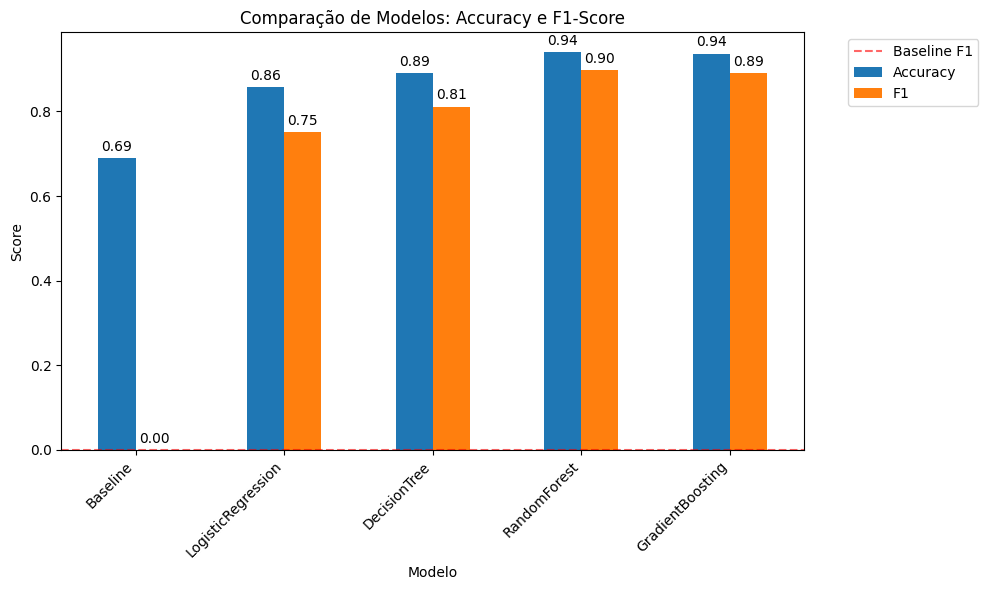

In [115]:
# Demonstração visual dos modelos
ax = results_df.plot(
    x="Modelo",
    y=["Accuracy", "F1"],
    kind="bar",
    figsize=(10,6)
)
metric = "F1"
ax.axhline(
    float(results_df[results_df["Modelo"] == "Baseline"][metric].iloc[0]),
    linestyle="--",
    color="red",
    alpha=0.6,
    label="Baseline F1"
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.title("Comparação de Modelos: Accuracy e F1-Score")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8.1 Impacto da variável _RecruitmentStrategy_

Como a variável _RecruitmentStrategy_ descreve uma característica do processo de recrutamento e não do candidato, foi realizado um experimento complementar sem sua utilização. O objetivo é verificar o impacto dessa variável no desempenho dos modelos e avaliar a capacidade preditiva baseada exclusivamente nas características dos candidatos.

In [116]:
# 1. Remover a variável RecruitmentStrategy
features_no_strategy = [
    col for col in features
    if col != "RecruitmentStrategy"
]

X_no_strategy = df[features_no_strategy].copy()
y_no_strategy = df[TARGET].copy()

# 2. Nova divisão treino/teste
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_strategy,
    y_no_strategy,
    test_size=0.2,
    random_state=SEED,
    stratify=y_no_strategy
)

# 3. Novo pré-processamento
num_cols_ns = X_train_ns.columns.tolist()

numeric_pipe_ns = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocess_ns = ColumnTransformer(transformers=[
    ("num", numeric_pipe_ns, num_cols_ns)
])

# 4. Baseline e modelos candidatos sem RecruitmentStrategy
baseline_ns = Pipeline(steps=[
    ("preprocess", preprocess_ns),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates_ns = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess_ns),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "DecisionTree": Pipeline(steps=[
        ("preprocess", preprocess_ns),
        ("model", DecisionTreeClassifier(max_depth=5, random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess_ns),
        ("model", RandomForestClassifier(n_estimators=100, random_state=SEED))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess_ns),
        ("model", GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ])
}

# 5. Treinamento e avaliação
results_no_strategy = []

# Baseline
baseline_ns.fit(X_train_ns, y_train_ns)
y_pred_baseline_ns = baseline_ns.predict(X_test_ns)

results_no_strategy.append({
    "Modelo": "Baseline",
    "Accuracy_sem_strategy": accuracy_score(y_test_ns, y_pred_baseline_ns),
    "F1_sem_strategy": f1_score(y_test_ns, y_pred_baseline_ns)
})

# Modelos candidatos
for name, model in candidates_ns.items():
    model.fit(X_train_ns, y_train_ns)
    y_pred_ns = model.predict(X_test_ns)

    results_no_strategy.append({
        "Modelo": name,
        "Accuracy_sem_strategy": accuracy_score(y_test_ns, y_pred_ns),
        "F1_sem_strategy": f1_score(y_test_ns, y_pred_ns)
    })

results_no_strategy_df = pd.DataFrame(results_no_strategy)

# 6. Comparação com os resultados anteriores
comparison_strategy = results_df.merge(
    results_no_strategy_df,
    on="Modelo",
    how="inner"
)

comparison_strategy["Diferença_F1"] = (
    comparison_strategy["F1_sem_strategy"] - comparison_strategy["F1"]
)

comparison_strategy = comparison_strategy.sort_values(
    by="F1",
    ascending=False
)

comparison_strategy

,Modelo,Accuracy,F1,Accuracy_sem_strategy,F1_sem_strategy,Diferença_F1
3,RandomForest,0.940000,0.897727,0.740000,0.417910,-0.479817
4,GradientBoosting,0.936667,0.891429,0.723333,0.457516,-0.433912
2,DecisionTree,0.890000,0.811429,0.736667,0.414815,-0.396614
1,LogisticRegression,0.856667,0.751445,0.720000,0.424658,-0.326788
0,Baseline,0.690000,0.000000,0.690000,0.000000,0.000000


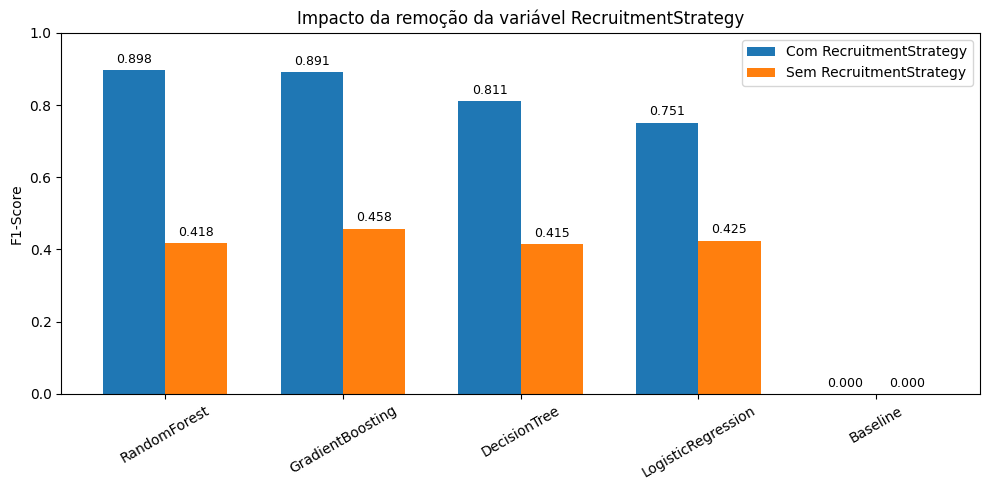

In [117]:
comparison_plot = comparison_strategy.copy()

# Ordenar pelo F1 original
comparison_plot = comparison_plot.sort_values("F1", ascending=False)

plt.figure(figsize=(10, 5))

x = np.arange(len(comparison_plot))
width = 0.35

plt.bar(
    x - width/2,
    comparison_plot["F1"],
    width,
    label="Com RecruitmentStrategy"
)

plt.bar(
    x + width/2,
    comparison_plot["F1_sem_strategy"],
    width,
    label="Sem RecruitmentStrategy"
)

plt.xticks(x, comparison_plot["Modelo"], rotation=30)
plt.ylim(0, 1)
plt.ylabel("F1-Score")
plt.title("Impacto da remoção da variável RecruitmentStrategy")
plt.legend()

# Exibir valores nas barras
for i, value in enumerate(comparison_plot["F1"]):
    plt.text(i - width/2, value + 0.02, f"{value:.3f}", ha="center", fontsize=9)

for i, value in enumerate(comparison_plot["F1_sem_strategy"]):
    plt.text(i + width/2, value + 0.02, f"{value:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 8.2 Análise dos resultados iniciais

- Todos os modelos avaliados superaram significativamente o baseline, demonstrando capacidade de identificar padrões relacionados à decisão de contratação.

- O F1-Score mostrou-se adequado para avaliação do problema, pois a variável-alvo apresenta desbalanceamento moderado entre contratados e não contratados.

- Não foram observados indícios relevantes de underfitting, especialmente nos modelos baseados em árvores, que apresentaram os melhores resultados.

- O tempo de treinamento foi baixo para todos os algoritmos, sendo compatível com o tamanho do dataset.

- Os resultados são coerentes com a EDA, que indicou associação entre algumas variáveis e a decisão de contratação.

- A variável _RecruitmentStrategy_ apresentou forte influência no desempenho dos modelos. Sua remoção provocou redução significativa do F1-Score, evidenciando sua relevância preditiva.

- A Random Forest apresentou o melhor desempenho inicial, seguida de forma muito próxima pelo Gradient Boosting.

# 9. Validação e otimização de hiperparâmetros

O modelo escolhido para otimização foi a Random Forest, por ter apresentado o melhor desempenho inicial entre os modelos avaliados, especialmente em termos de F1-Score, métrica principal adotada neste MVP.

**Hiperparâmetros ajustados:**

- **n_estimators:** número de árvores da floresta. Um maior número de árvores tende a aumentar a estabilidade e a capacidade de generalização do modelo, embora também aumente o tempo de processamento.

- **max_depth:** profundidade máxima das árvores. Controla a complexidade do modelo e ajuda a reduzir riscos de overfitting.

- **min_samples_split:** quantidade mínima de amostras necessária para realizar uma divisão em um nó interno da árvore. Valores maiores tornam o modelo mais conservador.

- **min_samples_leaf:** quantidade mínima de amostras exigida em cada folha. Atua como mecanismo de regularização, reduzindo a sensibilidade a ruídos presentes nos dados.

**Estratégia utilizada:** Grid Search com validação cruzada de 5 folds (GridSearchCV), utilizando o F1-Score como critério de seleção da melhor configuração. A validação cruzada permite avaliar o desempenho médio do modelo em diferentes subconjuntos dos dados de treinamento, reduzindo a dependência de uma única divisão treino/teste e fornecendo uma estimativa mais robusta da capacidade de generalização do modelo.

In [118]:
#  Otimização de hiperparâmetros - RandomForest
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
print(grid_rf.best_params_)

print("\nMelhor F1 médio na validação cruzada:")
print(grid_rf.best_score_)

Melhores hiperparâmetros:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Melhor F1 médio na validação cruzada:
0.8772510658066233


In [119]:
# Avaliação do modelo otimizado no conjunto de teste
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("F1 no teste:", f1_score(y_test, y_pred_best_rf))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_best_rf))

F1 no teste: 0.8926553672316384

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       207
           1       0.94      0.85      0.89        93

    accuracy                           0.94       300
   macro avg       0.94      0.91      0.92       300
weighted avg       0.94      0.94      0.94       300



In [120]:
rf_pipeline.fit(X_train, y_train)
# Random Forest original
y_pred_rf = rf_pipeline.predict(X_test)
f1_rf = f1_score(y_test, y_pred_rf)

# Random Forest otimizada
y_pred_best_rf = best_rf.predict(X_test)
f1_best_rf = f1_score(y_test, y_pred_best_rf)

comparacao = pd.DataFrame({
    "Modelo": [
        "Random Forest (Padrão)",
        "Random Forest (Otimizada)"
    ],
    "F1-Score": [
        round(f1_rf, 4),
        round(f1_best_rf, 4)
    ]
})

comparacao

ganho = ((f1_best_rf - f1_rf) / f1_rf) * 100

print(comparacao)
print(f"\nGanho percentual: {ganho:.2f}%")

                      Modelo  F1-Score
0     Random Forest (Padrão)    0.8977
1  Random Forest (Otimizada)    0.8927

Ganho percentual: -0.56%


## 9.1 Discussão da otimização

- O GridSearchCV avaliou diferentes combinações dos hiperparâmetros n_estimators, max_depth, min_samples_split e min_samples_leaf, buscando identificar a configuração com melhor desempenho para o modelo Random Forest.

- A busca foi realizada exclusivamente sobre o conjunto de treinamento utilizando validação cruzada com 5 folds, garantindo que o conjunto de teste permanecesse isolado durante todo o processo de otimização.

- O critério de seleção adotado foi o F1-Score, métrica escolhida por considerar simultaneamente precisão e recall, sendo adequada para avaliar o equilíbrio do desempenho do classificador.

- A melhor configuração encontrada foi:
n_estimators = 100;
max_depth = None;
min_samples_split = 2;
min_samples_leaf = 2;

- O melhor resultado obtido durante a validação cruzada foi um F1-Score médio de aproximadamente 0,877, indicando desempenho consistente entre os diferentes subconjuntos de treinamento.

- Na avaliação final do conjunto de teste, o modelo otimizado alcançou F1-Score de 0,893, demonstrando elevada capacidade preditiva para o problema de classificação de decisões de contratação.

- A comparação com a Random Forest utilizando parâmetros padrão mostrou desempenho bastante semelhante, sugerindo que a configuração original do algoritmo já apresentava um nível de desempenho próximo ao ótimo para este conjunto de dados.

- Embora a otimização não tenha produzido ganhos expressivos no conjunto de teste, ela permitiu validar que o modelo escolhido é robusto e que os hiperparâmetros padrão da Random Forest já se mostram adequados para o problema analisado.

# 10. Avaliação final no conjunto de teste

Após a seleção e otimização do modelo, a Random Forest otimizada foi escolhida como solução final para o problema de previsão de contratação. Nesta etapa, o modelo é avaliado no conjunto de teste, permitindo analisar seu desempenho em dados não utilizados durante o treinamento, bem como discutir seus erros, capacidade de generalização e limitações.

In [121]:
# Modelo final escolhido
final_model = best_rf

# Previsões
y_pred_final = final_model.predict(X_test)

print("=== Relatório de Classificação — Modelo Final (Random Forest Otimizada) ===")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Não Contratar", "Contratar"]
    )
)

print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_final):.4f}")

=== Relatório de Classificação — Modelo Final (Random Forest Otimizada) ===
               precision    recall  f1-score   support

Não Contratar       0.94      0.98      0.96       207
    Contratar       0.94      0.85      0.89        93

     accuracy                           0.94       300
    macro avg       0.94      0.91      0.92       300
 weighted avg       0.94      0.94      0.94       300

Accuracy : 0.9367
Precision: 0.9405
Recall   : 0.8495
F1-Score : 0.8927


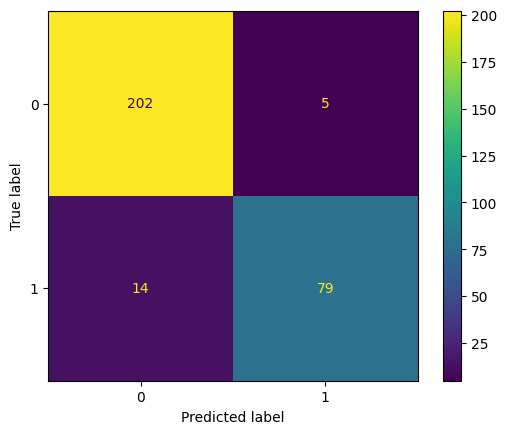

In [122]:
# Matriz de Confusão.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final
)

plt.show()

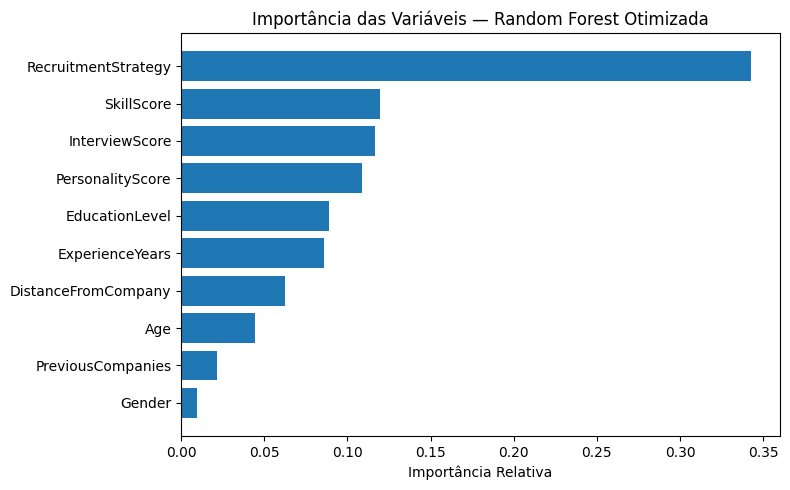

,Feature,Importância
9,RecruitmentStrategy,0.343009
7,SkillScore,0.119276
6,InterviewScore,0.116570
8,PersonalityScore,0.108620
2,EducationLevel,0.088948
3,ExperienceYears,0.085710
5,DistanceFromCompany,0.062164
0,Age,0.044339
4,PreviousCompanies,0.021596
1,Gender,0.009770


In [123]:
# Importância das variáveis

rf_model = final_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importância": rf_model.feature_importances_
}).sort_values("Importância", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    feature_importance["Feature"],
    feature_importance["Importância"]
)

ax.set_title("Importância das Variáveis — Random Forest Otimizada")
ax.set_xlabel("Importância Relativa")

plt.tight_layout()
plt.show()

display(feature_importance.sort_values("Importância", ascending=False))

## 10.1 Análise de Erros e Limitações

A matriz de confusão e as métricas de desempenho permitem identificar os principais acertos e erros do modelo final, além de evidenciar algumas limitações da solução proposta.

- **Falsos Negativos (FN):** foram identificados 14 casos em que candidatos que deveriam ser classificados como "Contratar" foram classificados como "Não Contratar". Este é o principal tipo de erro observado pelo modelo e pode representar a perda de candidatos potencialmente adequados para a vaga.

- **Falsos Positivos (FP):** apenas 5 candidatos foram classificados como "Contratar" quando deveriam ser classificados como "Não Contratar". Esse resultado indica que o modelo é relativamente conservador ao recomendar contratações, reduzindo o risco de selecionar candidatos inadequados.

- **Overfitting:** não foram observados indícios relevantes de overfitting. O F1-Score médio obtido durante a validação cruzada (0,877) foi semelhante ao desempenho observado no conjunto de teste (0,893), indicando boa capacidade de generalização para dados não vistos anteriormente.

- **Underfitting:** também não foram identificados sinais de underfitting, uma vez que o modelo apresentou elevada precisão, recall e F1-Score, demonstrando capacidade de capturar adequadamente os padrões presentes nos dados.

- **Dependência da variável RecruitmentStrategy:** a análise de importância das variáveis mostrou que _RecruitmentStrategy_ foi o atributo mais relevante para as previsões do modelo. Além disso, sua remoção provocou redução no desempenho dos modelos avaliados, indicando forte influência dessa variável na tomada de decisão.

- **Dataset sintético:** o conjunto de dados utilizado possui caráter educacional e representa uma simplificação de processos reais de recrutamento. Dessa forma, os resultados obtidos devem ser interpretados como uma prova de conceito e não como uma solução pronta para utilização em ambiente produtivo.

- **Validação externa:** o modelo foi treinado e avaliado utilizando apenas uma base de dados. Para utilização em cenários reais, seria recomendável validar o desempenho em diferentes conjuntos de dados e contextos de recrutamento.

- **Variáveis sensíveis:** a variável _Gender_ foi utilizada durante o treinamento, embora tenha apresentado baixa importância relativa. Em aplicações reais, seria necessária uma análise de viés algorítmico para garantir que o modelo não produza decisões discriminatórias ou inconsistentes com princípios éticos e regulatórios.

# 11. Comparação final dos modelos


In [124]:
# Comparação dos modelos
modelos_comparacao = {
    "Baseline": baseline,
    "Logistic Regression": candidates["LogisticRegression"],
    "Decision Tree": candidates["DecisionTree"],
    "Random Forest": candidates["RandomForest"],
    "Gradient Boosting": candidates["GradientBoosting"],
    "Random Forest Otimizada": best_rf
}

comparacao_final = []

for nome, modelo in modelos_comparacao.items():
    inicio = time.perf_counter()
    modelo.fit(X_train, y_train)
    tempo_treino = time.perf_counter() - inicio

    y_pred = modelo.predict(X_test)

    comparacao_final.append({
        "Modelo": nome,
        "Métrica principal (F1)": round(f1_score(y_test, y_pred), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "Tempo de treino (s)": round(tempo_treino, 4)
    })

comparacao_final_df = pd.DataFrame(comparacao_final)

comparacao_final_df.sort_values(
    by="Métrica principal (F1)",
    ascending=False
)

,Modelo,Métrica principal (F1),Accuracy,Precision,Recall,Tempo de treino (s)
3,Random Forest,0.8977,0.9400,0.9518,0.8495,0.3199
5,Random Forest Otimizada,0.8927,0.9367,0.9405,0.8495,0.2774
4,Gradient Boosting,0.8914,0.9367,0.9512,0.8387,0.3441
2,Decision Tree,0.8114,0.8900,0.8659,0.7634,0.0129
1,Logistic Regression,0.7514,0.8567,0.8125,0.6989,0.0083
0,Baseline,0.0000,0.6900,0.0000,0.0000,0.0086


A comparação final mostra que os modelos baseados em árvores apresentaram melhor desempenho geral em relação ao baseline e à Regressão Logística. A Random Forest padrão obteve o maior F1-Score no conjunto de teste, enquanto a Random Forest otimizada apresentou desempenho muito próximo, sendo selecionada por ter sido ajustada de forma sistemática por validação cruzada.

O baseline apresentou F1-Score igual a zero, pois classificou todos os casos na classe majoritária, reforçando a necessidade de modelos supervisionados capazes de aprender padrões relevantes nos dados. A diferença entre a Random Forest padrão e a otimizada foi pequena, indicando que o algoritmo já apresentava desempenho robusto mesmo com seus hiperparâmetros padrão.

# 12. Boas práticas e rastreabilidade

Esta seção registra as principais decisões técnicas adotadas durante o desenvolvimento do MVP, permitindo rastreabilidade, reprodutibilidade e compreensão das escolhas realizadas ao longo do projeto.

## Informações gerais

- **Seed utilizada:** 42
- **Problema:** Classificação supervisionada para previsão de contratação de candidatos.
- **Variável alvo:** _HiringDecision_
- **Dataset:** Predicting Hiring Decisions in Recruitment Data
- **Ambiente:** Google Colab
- **Bibliotecas principais:** Pandas, NumPy, Matplotlib, Seaborn e Scikit-Learn.

## Principais decisões de pré-processamento

- Verificação de valores ausentes e inconsistências.
- Separação entre variáveis explicativas e variável alvo.
- Divisão dos dados em conjuntos de treino e teste utilizando estratificação para preservar a distribuição das classes.
- Utilização de Pipeline para garantir que o pré-processamento fosse aplicado de forma consistente durante treinamento e validação.

## Modelos avaliados

- Baseline (Dummy Classifier)
- Regressão Logística
- Decision Tree
- Random Forest
- Gradient Boosting
- Random Forest Otimizada

## Hiperparâmetros relevantes

### Random Forest

- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf

Melhor configuração encontrada:

- n_estimators = 100
- max_depth = None
- min_samples_split = 2
- min_samples_leaf = 2

## 13. Conclusão

- O objetivo deste MVP foi desenvolver um modelo capaz de prever a decisão de contratação de candidatos com base em informações do processo seletivo.

- A análise exploratória indicou que variáveis relacionadas ao desempenho técnico, desempenho em entrevistas, características comportamentais e estratégia de recrutamento poderiam influenciar a contratação.

- Os resultados obtidos confirmaram essas hipóteses, destacando principalmente as variáveis _RecruitmentStrategy_, _SkillScore_, _InterviewScore_ e _PersonalityScore_ como as mais relevantes para as previsões.

- Entre os modelos avaliados, a **Random Forest** apresentou o melhor desempenho geral, alcançando aproximadamente **89% de F1-Score** no conjunto de teste.

- O modelo selecionado superou significativamente o baseline, demonstrando capacidade de aprender padrões relevantes presentes nos dados e gerar previsões úteis para apoiar decisões de recrutamento.

- A análise realizada sem a variável _RecruitmentStrategy_ mostrou redução de desempenho, reforçando a importância dessa informação no processo de contratação.

- Não foram observados indícios relevantes de overfitting ou underfitting, uma vez que os resultados da validação cruzada e do conjunto de teste permaneceram consistentes.

- Como principais limitações, destacam-se o uso de um dataset sintético, a ausência de validação em bases externas e a forte dependência da variável _RecruitmentStrategy_.

- Como trabalhos futuros, recomenda-se validar o modelo em dados reais, ampliar o conjunto de variáveis analisadas, realizar estudos de fairness algorítmica e explorar técnicas adicionais de otimização e interpretabilidade.

- Em síntese, os resultados demonstram que técnicas de Machine Learning podem auxiliar processos de recrutamento, contribuindo para uma análise mais estruturada dos fatores que influenciam a decisão de contratação.